# Power analysis attack on AES with custom SBox 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys

sys.path.append( '../ciphers/AES_python' )
sys.path.append( '../sca_python' )

# Set the S-Box to test
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")
project_file = "../../build/sca_test/sca_test_CW305_"+sbox_id+".cwp"
bitstream = r"../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_"+sbox_id+"_lut.bit"


## Picoscope and CW305 initialization

In [2]:
from pico_api import PS5000aWrapper
from CW305_api import CW305Wrapper

from picoscope import ps5000a

#ps = ps5000a.PS5000a()
#ps.close()
try:
    # Initialize picoscope
    ps = PS5000aWrapper()
    ps.get_unitInfo()
    ps.scope_setup()
    # Initialize CW305
    cw305 = CW305Wrapper(ps, bitstream)
except ModuleNotFoundError as e:
    print(e)

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.7.5057
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : KU687/0175
CalDate                       : 26Apr23
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0


(ChipWhisperer Target WARNING|File CW305.py:345) Verilog defines not found in default location (/home/mattia-mirigaldi/.pyenv/versions/cw/lib/python3.9/site-packages/chipwhisperer/../../hardware/victims/cw305_artixtarget/fpga/common/cw305_defines.v).
Using defines from CW305.py.If this isn't what you want, either add 'slurp=False', or provide defines location in 'defines_files'


True


## Optional online phase : AES power traces capture

In [3]:
# If capure is set to True, the script will capture data from the PicoScope
capture = False
# If save_dataset is set to True, the script will save the captured data to a .dat file
save_dataset = True

### Configuration

In [4]:
sys.path.append('../sca_python/utils')
from dat_tracereader import dat_tracereader

n_trc = 1000  # number of traces to capture or read from dataset
# Configuration parameters
num_samples = ps.nSamples  # number of samples per trace
pt_len = 16  # size of the plaintext in bytes
ct_len = 16  # size of the ciphertext in bytes
key_len = 16  # size of the key in bytes
# Allocate memory for traces and data
trace = np.empty((n_trc, num_samples), dtype=np.float64)  
plaintext = np.empty((n_trc, pt_len), dtype=np.uint8)  
ciphertext = np.empty((n_trc, ct_len), dtype=np.uint8)  
key = np.empty(key_len, dtype=np.uint8) 

if not capture:
    try:
        reader = dat_tracereader()
        reader.open_ro("dataset/aes_"+sbox_id+".dat")
        trace, key, plaintext, ciphertext =  reader.read_traces(n_trc)
        reader.close()
    except Exception as e:
        print("Error loading dataset: ", e)

### Capture power traces

In [6]:
from tqdm.notebook import tnrange
import chipwhisperer as cw
from Crypto.Cipher import AES
from AES_golden import AES_golden_model
import time

if capture:
    # Initialize key,text pair generator
    ktp = cw.ktp.Basic()
    key, plaintext[0] = ktp.next()

    # Initialize the AES software emulated cipher
    cipher = AES_golden_model()

    # Each element of the key is converted to a 2-digit hex string 
    formatted_key = ''.join(format(el, '02x') for el in key)
    print("Key: ", [ hex(subkey) for subkey in key])

    # Write the key to the CW305
    cw305.set_key(key)

    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(plaintext[0])

    for i in tnrange(n_trc, desc='Capturing traces'):
        ciphertext[i], trace[i] = cw305.capture_trace(plaintext[i])
        # Sanity check with expected ciphertext
        formatted_pt = (format(el, '02x') for el in plaintext[i])
        text = [int(subbyte, 16) for subbyte in formatted_pt]
        assert (list(ciphertext[i]) == list(cipher.encrypt(formatted_key, text, tested_sbox))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(list(ciphertext[i]), list(plaintext[i]))
        if (i < n_trc-1):
            _ , plaintext[i+1] = ktp.next() 

    # Disconnect CW305 and picoscope
    cw305.dis()
    ps.dis()

    # If save_dataset is set to True, the attack data are stored to a .dat file
    if (save_dataset):
        try:
            writer = dat_tracereader()
            key = np.array(key, dtype=np.uint8)
            writer.create(
                pathname="dataset/aes_"+sbox_id+".dat",
                trace_len=int(num_samples),
                sample_type='d',
                key_len=key_len,
                plaintext_len=pt_len,
                ciphertext_len=ct_len
            )
            writer.write_traces(trace, key, plaintext, ciphertext)
            print("Traces written:", writer.num_traces)
            writer.close()
        except Exception as e:
            print("Error saving dataset: ", e)

## Offline phase : attack on captured traces

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
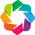

In [7]:
import os
import chipwhisperer.analyzer as cwa
import chipwhisperer as cw
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds
from analyzer.utils.sca_plots import sca_plot

### Plotting power traces captured (40 samples overlapped)

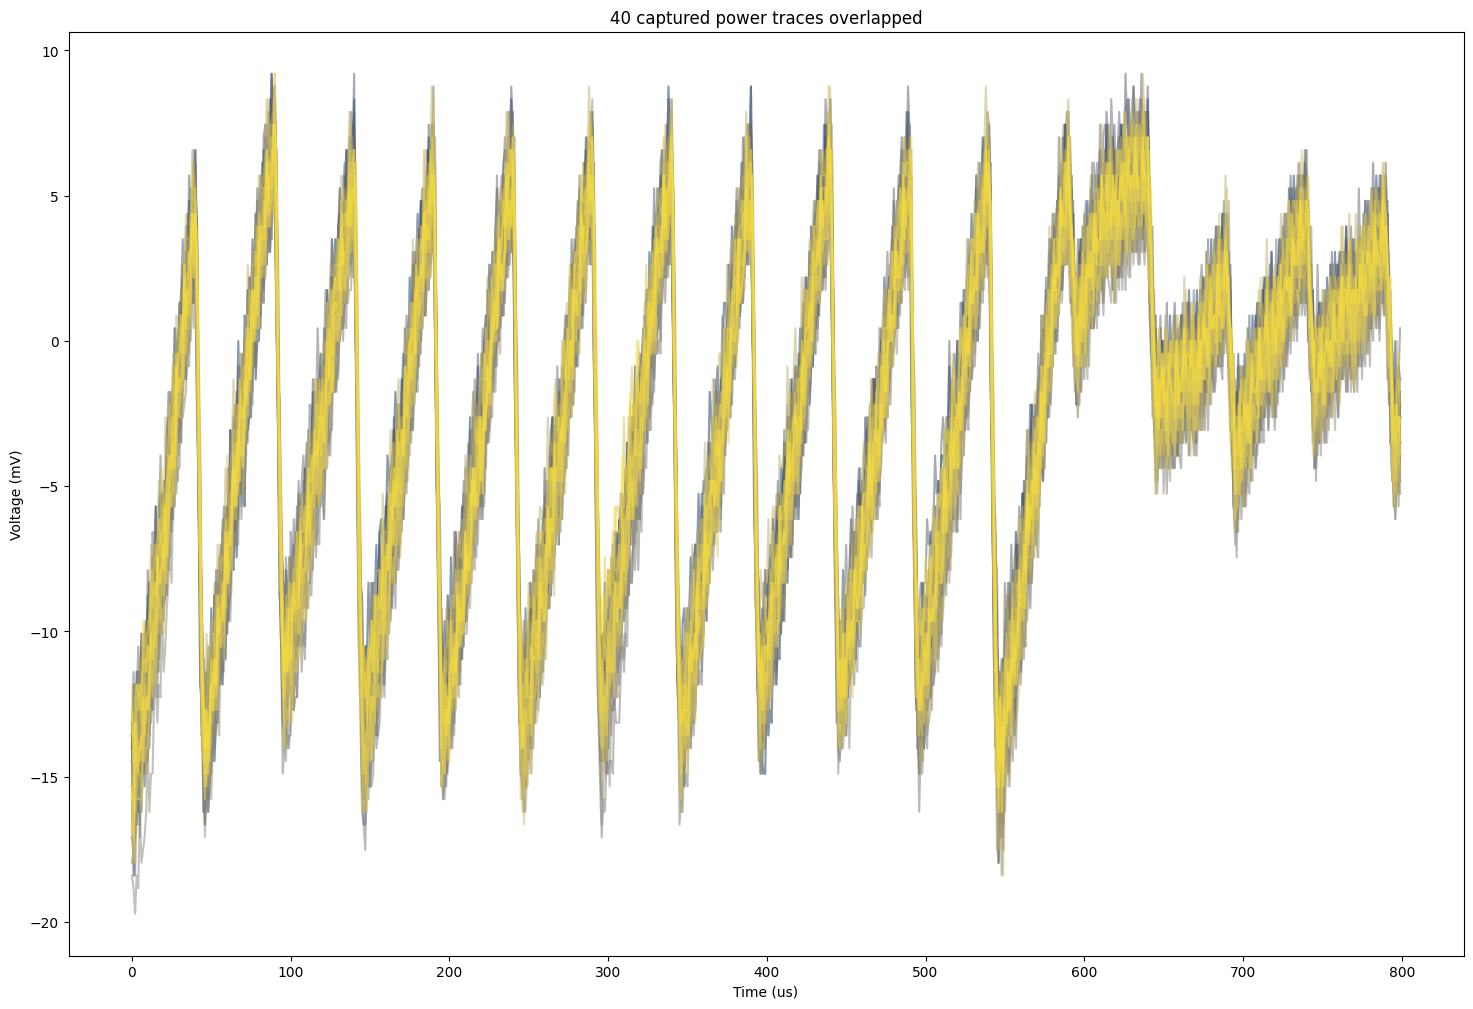

<Figure size 640x480 with 0 Axes>

In [9]:
sca_plt = sca_plot()
power_plt = sca_plt.power_traces_overlapped(ps.get_samplingInterval(), trace, finish=800)
power_plt.show()
# Ensure the Graphs directory exists
os.makedirs("Graphs", exist_ok=True)
power_plt.savefig("Graphs/power_traces_overlapped"+tested_sbox+".png")

# Hamming distance attack : 
## state difference leakage model on last round due to missing mix column operation

quindi io ho una matrice di tracce, devo calcolarmi per ogni input il leakage, che significa semplicement calcolarmi l'hamming distance tra il ciphertext e l'inverso dell'sbox con l'ipotesi della chiave. Questa cosa la devo fare per tutte le chiavi
Quindi recap, 
prima mi costruisco la matrice di potenza ipotizzata, lungha quanto le chiavi e alta quanto gli input

per ogni possibile sample
    correlazione tra potenza in quel momento e potenza ipotizzata

    per ogni possibile key hypothesis
        mi calcolo la correlazione tra hd con questa chiave e la colonna al sample s e 
La mia matrice di correlazione deve essere alta quanto le chiavi e lunga quanto i samples 
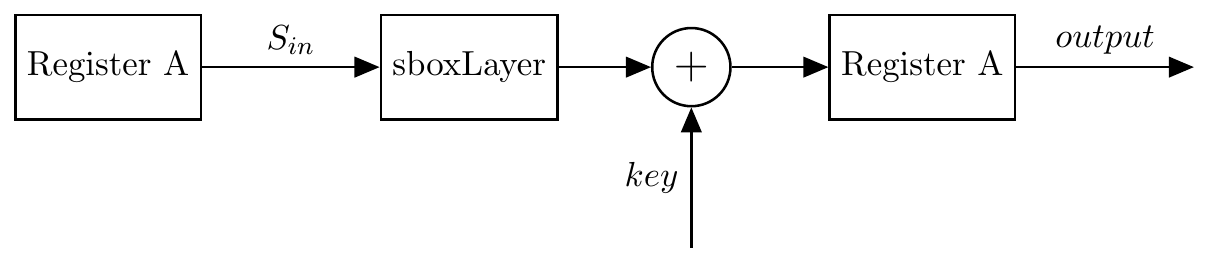

In [ ]:
# The hamming distance is computed as the number of bits that flipped between two consecutive states
# The output state (round 10) is known and can be predicted previoust state (round 9)

n_candidates = 256

# Create list of hamming weight
hw = [bin(i).count("1") for i in range(n_candidates)]

def hamming_distance(a,b):
    return hw[(a^b)]

In [ ]:
import sys
from tqdm.notebook import tqdm
sys.path.append('/home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_python/analyzer/attack/aes')
from sbox_modified_funcs import inv_sbox_lut

y_hd = np.empty((n_trc, n_candidates), dtype=np.uint8)

# Calculate the hamming distance between the ciphertext and the predicted output for each key guess
for i in tqdm(range(n_trc)):
    for k in range(n_candidates):
        y_predicted = np.uint8(inv_sbox_lut(ciphertext[i][0] ^ k, tested_sbox))
        y_hd[i, k] = hamming_distance(ciphertext[i][0], y_predicted)

# Calculate the correlation between the power traces and the hamming distance
r = np.empty((n_smp, n_candidates), dtype=np.float64)
for k in tqdm(range(n_candidates), desc='Computing correlations'):
    r = np.corrcoef() 
